In [ ]:
#Added Planner

In [141]:
from dotenv import load_dotenv 
from langchain_groq import ChatGroq 
from langchain_classic.prompts import ChatPromptTemplate 
from langgraph.graph import StateGraph,END, START 
from langgraph.checkpoint.memory import MemorySaver,InMemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver 
from typing import TypedDict,List,Literal,Optional,Annotated,Dict 
from langgraph.graph.message import add_messages
from langchain_google_genai import ChatGoogleGenerativeAI 
from pydantic import Field,BaseModel
from langchain_core.messages import BaseMessage,HumanMessage,SystemMessage,AIMessage,trim_messages

from langchain_classic.tools import tool
from tavily import TavilyClient
load_dotenv()
import os 
from langgraph.prebuilt import ToolNode, tools_condition
import sqlite3
import requests 
from langchain_classic.prompts import ChatPromptTemplate,MessagesPlaceholder

In [93]:
#firstly let make a connection with our local db 
connection=sqlite3.connect(database="context_memory.db",check_same_thread=False)
sqlite_checkpointer = SqliteSaver(conn=connection)

In [94]:
planner=ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite',api_key=os.getenv('GOOGLE_API_KEY2'))

In [98]:
llm=ChatGoogleGenerativeAI(model='gemini-3.5-flash-lite',api_key=os.getenv('GOOGLE_API_KEY'))
#and also another llm gemini-3.5-flash-lite 
# llm.invoke('hi')

In [99]:
class GraphSchema(TypedDict): 
    messages: Annotated[list[BaseMessage], add_messages]
    plan: str 

In [ ]:

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}



@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={os.getenv('ALPHA_VANTAGE_API_KEY')}"
    r = requests.get(url)
    return r.json()



@tool 
def get_weather(location: str)-> dict:
    """"Fetch the current weather for a given city using the openweather api """
    api_key=os.environ['WEATHER_API_KEY']
    url = f"https://api.weatherapi.com/v1/current.json"
    params = {
        "key": api_key,
        "q": location,
        "aqi": "no"  # Optional: disables air quality data
    }
    response = requests.get(url, params=params)
    data = response.json()
    return data

@tool
def web_search(query: str) -> Dict:
    """Perform a web search for the given query and return the relevant web results."""

    tavily_api_key=os.getenv('TAVILY_API_KEY')
    client = TavilyClient(tavily_api_key)
    response = client.search(
        
        query=query,
        search_depth="advanced",
        chunks_per_source=5,
        max_results=5
    )
    return response

In [101]:
#lets bind the llm with tools 


tools=[web_search,get_stock_price,get_weather,calculator]
main_llm=llm.bind_tools(tools)

In [115]:
from langchain_core.messages import trim_messages

def Plan(state: GraphSchema) -> GraphSchema:

    # Same safe trim as Chat() -> avoids orphaned tool_call/tool_response 400 error
    messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=len,
        max_tokens=5,
        start_on="human",
        end_on=("human", "tool"),
        include_system=True,
    )

    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """
You are the Planner for a multi-step problem-solving agent.

Use the conversation history and latest user message to understand
the user's task and create an execution plan.

Available tools:
- web_search
- get_stock_price
- get_weather
- calculator

Do not answer the question.
Only create the plan.

Output:

Goal: <one sentence>
Plan:
1. [tool: <tool_name or "none">] <what to do>
2. [tool: <tool_name or "none">] <what to do>
"""
        ),
        MessagesPlaceholder("messages")
    ])

    chain = prompt | planner

    response = chain.invoke({
        "messages": messages
    })

    return {
        "plan": response.content
    }

In [116]:

def Chat(state: GraphSchema) -> GraphSchema:

    # Trim safely: start on a Human turn, end on Human/Tool
    # -> avoids Gemini's "orphaned tool_call" 400 error
    messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=len,          # counts messages, not tokens
        max_tokens=5,                # = max messages to keep
        start_on="human",            # never start mid tool-loop
        end_on=("human", "tool"),    # never end on unresolved tool_call
        include_system=True,
    )

    plan = state.get("plan", "")

    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """
You are the main problem-solving agent.

You have been given a plan by a Planner agent. Follow it step by step,
using the available tools when the plan calls for them:

- web_search
- get_stock_price
- get_weather
- calculator

Plan to follow:
{plan}

Use the conversation history for context. Execute the plan, call tools
as needed, and clearly explain your reasoning at each step before giving
the final answer.
"""
        ),
        MessagesPlaceholder("messages")
    ])

    # main_llm must be tool-bound, e.g. main_llm.bind_tools([...])
    chain = prompt | main_llm

    response = chain.invoke({
        "plan": plan,
        "messages": messages
    })

    return {"messages": response}

In [117]:
tool_node = ToolNode(tools) 

In [118]:



graph=StateGraph(state_schema=GraphSchema) 

#now lets make node 
graph.add_node('planner',Plan)
graph.add_node('chat_with_llm',Chat)
graph.add_node("tools", tool_node)
#now the graph 
graph.add_edge(START,'planner') 
graph.add_edge('planner','chat_with_llm')
graph.add_conditional_edges("chat_with_llm",tools_condition)

graph.add_edge('tools','chat_with_llm') 





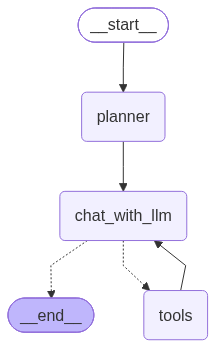

In [119]:
workflow=graph.compile(checkpointer=sqlite_checkpointer)
workflow

In [ ]:
configuration={'configurable':{'thread_id':1}}

In [132]:
final_state=workflow.invoke(input={'messages':[HumanMessage(content='please tell me about the weather of alwar and also aou the laest news realted to the indian cricket both men and women and their upcoming match schedule')]},config=configuration)

In [138]:
final_state

{'messages': [HumanMessage(content='please tell me about the weather of alwar and also aou the laest news realted to the indian cricket both men and women', additional_kwargs={}, response_metadata={}, id='c3dae85d-dd5c-497f-a1b1-10df1c36320b'),
  AIMessage(content=[{'type': 'text', 'text': 'Step 1: Get the current weather forecast for Alwar using the `get_weather` tool.'}], additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "Alwar"}'}, '__gemini_function_call_thought_signatures__': {'call_36787': 'El4KXAERTTIPILOus6pVLA+aZDe5yRdFCxHG1YQxj6vuAfgxRKAN4F9H0rsLd51XlIwy6SoUnFdVh5MLb8lHDFdst/wuwlxnFW/G3O/i7dUzh2KKGJrLDsVVKf+5LZfG'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a08771-5431-7010-89ce-5f3bf6162354-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Alwar'}, 'id': 'call_36787', 'type': 'tool_call'}], invalid_tool_calls=[], us

In [139]:
final_state['messages'][-1].content[0]['text']

"Here is the latest information regarding the weather in Alwar, alongside the news and upcoming match schedules for the Indian men's and women's cricket teams:\n\n### 1. Weather in Alwar, Rajasthan\n* **Current Conditions:** Overcast skies with a temperature around **30.3°C** (feels like ~30.7°C).\n* **Wind & Humidity:** Winds are coming from the West at roughly **17.6 km/h** with gusts up to nearly 50 km/h, and humidity sits at **45%**. \n* **Rain Outlook:** The chance of rain is very low (around 9%), making it a warm and breezy overcast evening.\n\n---\n\n### 2. Indian Women's Cricket Team: News & Schedule\n* **Latest News:** The Indian women's team has been actively competing in the **Women’s Asia Cup**, putting on stellar performances. Notably, opener Smiriti Mandhana recently broke records by surpassing Mithali Raj to become the leading run-getter in women's international cricket, alongside dominant wins against teams like Pakistan and Thailand.\n* **Upcoming Matches (Asian Games 

In [140]:
from IPython.display import display,Markdown 
display(Markdown(final_state['messages'][-1].content[0]['text']))

Here is the latest information regarding the weather in Alwar, alongside the news and upcoming match schedules for the Indian men's and women's cricket teams:

### 1. Weather in Alwar, Rajasthan
* **Current Conditions:** Overcast skies with a temperature around **30.3°C** (feels like ~30.7°C).
* **Wind & Humidity:** Winds are coming from the West at roughly **17.6 km/h** with gusts up to nearly 50 km/h, and humidity sits at **45%**. 
* **Rain Outlook:** The chance of rain is very low (around 9%), making it a warm and breezy overcast evening.

---

### 2. Indian Women's Cricket Team: News & Schedule
* **Latest News:** The Indian women's team has been actively competing in the **Women’s Asia Cup**, putting on stellar performances. Notably, opener Smiriti Mandhana recently broke records by surpassing Mithali Raj to become the leading run-getter in women's international cricket, alongside dominant wins against teams like Pakistan and Thailand.
* **Upcoming Matches (Asian Games 2026):** Full-strength squads are headed to the Aichi-Nagoya Asian Games. The women's tournament kicks off with India facing tournament hosts **Japan on September 17, 2026**. 
  * *Semi-finals:* September 20, 2026
  * *Medal Matches (Bronze / Gold):* September 22, 2026

---

### 3. Indian Men's Cricket Team: News & Schedule
* **Latest News & Context:** The men's team continues to manage a packed and demanding white-ball and red-ball calendar, following massive fixtures earlier in the year like the T20 World Cup and domestic commitments like the IPL.
* **Upcoming Match Schedule:** 
  * **England Tour (July):** A multi-format series featuring T20Is and ODIs throughout July (e.g., T20Is starting July 1, ODIs starting July 14).
  * **Home Series (September–October):** Home T20I and ODI series against West Indies and Afghanistan are lined up.
  * **Asian Games (September–Nahoya):** The men's cricket tournament at the Asian Games begins on **September 24, 2026**, with India sending a strong squad to defend their gold medal standing.